# Twitter Sentiment Analysis of Tech Product Discussions Using Machine Learning

## AUTHORS:
* FAITH NG'ENDO
* ALLAN MUCHIRI
* ANTHONY NJERU
* WILLIAM NYAWIR
* SARAH OWENDI

# Business Problem

* How can we automatically analyze and classify Twitter sentiment about Apple and Google products into positive, negative, or neutral in order to help businesses quickly understand public opinion and improve decision-making?

# Problem statement

Social media platforms such as Twitter generate large volumes of user-generated content where customers freely express their opinions about products and services. For major technology companies like Apple and Google, these opinions provide valuable insight into public perception of their products.

However, manually analyzing thousands of tweets is inefficient, time-consuming, and not scalable. Businesses need a way to automatically understand whether customer feedback is positive, negative, or neutral.

This project aims to solve this problem by building a Natural Language Processing (NLP) model that can accurately classify the sentiment of tweets related to Apple and Google products. The model will help automate sentiment analysis and provide timely insights into customer opinions.

## Main Objective

* Our main objective is to build a Natural Language Processing (NLP) model that classifies the sentiment of tweets about Apple and Google products.

## Business Understanding

Companies like Apple and Google operate in highly competitive technology markets, where public perception of their products plays a critical role in success. Customer opinions shared on social media platforms such as Twitter strongly influence product adoption, brand reputation, customer trust, and overall marketing effectiveness.

Currently, organizations often rely on manual review of social media feedback or basic analytics tools to understand customer sentiment. However, these approaches are not efficient because they are slow, inconsistent, and unable to scale to thousands of tweets generated daily.

To address this challenge, there is a need for an automated sentiment analysis system that can classify tweets as positive, negative, or neutral. Such a system enables businesses to:

Monitor brand perception in real time
Detect negative feedback early
Improve customer experience
Support data-driven marketing and product decisions

By automating sentiment analysis, companies can respond faster to customer opinions and make more informed strategic decisions.



### TABLE OF CONTENT
1. [Data Cleaning, Exploratory Data Analysis, and Merging](#1)
2. [Data Cleaning: Dataset 1 (Provided.csv)](#2)
3. [Data Cleaning: Dataset 2 (Data2.csv)](#3)
4. [Exploratory Data Analysis](#4)
5. [Analysis: Dataset 2 (General Sentiment)](#5)
6. [Merging Datasets](#6)
7. [Visualizasions](#7)
8. [Export Merged Dataset](#8)
9. [Machine learning and data preparation for modeling](#9)
10. [Feature Extraxtion](#10)
11. [ Model 1 — VADER Rule-Based Baseline (NLTK)](#11)
12. [Model 2 — LightGBM Gradient Boosting](#12)
13. [Model 3 — Logistic Regression Multiclass (scikit-learn)](#13)
14. [Model 4 — XGBoost Gradient Boosting](#14)
15. [Model 5 — Naive Bayes Binary Classifier (scikit-learn)](#15)
16. [Final Comparison  and summary](#16)
17. [Recomendation and Conclusion](#17)

<a id='1'></a>
## 1. Data Cleaning, Exploratory Data Analysis, and Merging

This section is for cleaning, analyzing, and merging two tweet sentiment datasets.

In [7]:
# loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [8]:
# Loading datasets
df_provided = pd.read_csv('Data/Provided.csv', encoding='latin-1')
df_data2 = pd.read_csv('Data/Data2.csv', encoding='latin-1')


In [9]:
df_provided.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [10]:
df_provided.info()
df_provided.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


(9093, 3)

In [11]:
df_data2.head()

,id,date,text,target
0,0,2009-06-20,My concealer just broke!,0
1,1,2009-06-21,Mommy leaves soon,0
2,2,2009-06-03,@Boogaloo1 Not here it ain't! I've got an epi...,0
3,3,2009-06-16,I want my Blackberry back!!,0
4,4,2009-06-16,@Veganluke I can't even skype still dont have...,0


In [12]:
df_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      10000 non-null  int64 
 1   date    10000 non-null  object
 2   text    10000 non-null  object
 3   target  10000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 312.6+ KB


In [13]:
df_data2.shape

(10000, 4)

<a id='2'></a>
## 2. Data Cleaning: Dataset 1 (Provided.csv)

Cleaning the first dataset by removing duplicates, handling missing values, and standardizing emotion labels.

In [14]:
df1 = df_provided.copy()

In [15]:
# Checking for missing values
df1.isnull().sum().sum()

np.int64(5803)

In [16]:
# Checking for duplicates
df1.duplicated().sum()

np.int64(22)

In [17]:
# Remove rows where tweet_text is missing
df1 = df1[df1['tweet_text'].notna()].copy()

In [18]:
# Clean text first
df1['tweet_text'] = df1['tweet_text'].str.strip()
df1['tweet_text_clean'] = df1['tweet_text'].str.lower()

In [19]:
# Remove duplicates based on tweet_text
df1 = df1.drop_duplicates(subset=['tweet_text']).copy()

In [20]:
# Handle missing categorical values
df1['emotion_in_tweet_is_directed_at'] = df1['emotion_in_tweet_is_directed_at'].fillna('Unknown')
df1['is_there_an_emotion_directed_at_a_brand_or_product'] = df1['is_there_an_emotion_directed_at_a_brand_or_product'].fillna('Unknown')


In [21]:
# Handle missing values in categorical columns
df1['emotion_in_tweet_is_directed_at'] = df1['emotion_in_tweet_is_directed_at'].fillna('Unknown')
df1['is_there_an_emotion_directed_at_a_brand_or_product'] = df1['is_there_an_emotion_directed_at_a_brand_or_product'].fillna('Unknown')


In [22]:
# Standardize emotion labels
emotion_mapping = {
    'Negative emotion': 'Negative',
    'Positive emotion': 'Positive',
    'No emotion toward brand or product': 'Neutral',
    "I can't tell": 'Uncertain',
    'Unknown': 'Unknown'
}

df1['is_there_an_emotion_directed_at_a_brand_or_product'] = (df1['is_there_an_emotion_directed_at_a_brand_or_product']
    .map(emotion_mapping).fillna('Unknown'))


In [23]:
# Add features
df1['dataset_source'] = 'Provided'
df1['text_length'] = df1['tweet_text'].str.len()
df1['word_count'] = df1['tweet_text'].str.split().str.len()

In [24]:
df1.shape
df1.isnull().sum().sum()

np.int64(0)

In [26]:
df1.duplicated(subset=['tweet_text']).sum()

np.int64(0)

<a id='3'></a>
## 3. Data Cleaning: Dataset 2 (Data2.csv)

Cleaning the second dataset by removing duplicates, handling missing values, and standardizing sentiment labels.

In [27]:
df2 = df_data2.copy()

In [28]:
df2.isnull().sum().sum()

np.int64(0)

In [29]:
df2.duplicated().sum()

np.int64(0)

In [30]:
# Remove missing text
df2 = df2[df2['text'].notna()].copy()

In [31]:
# Clean text
df2['text'] = df2['text'].str.strip()
df2['text_clean'] = df2['text'].str.lower()

In [32]:
# Remove duplicates
df2 = df2.drop_duplicates(subset=['text_clean']).copy()

In [33]:
# Convert date
df2['date'] = pd.to_datetime(df2['date'], errors='coerce')

In [34]:
# 5. Map sentiment
sentiment_mapping = {
    0: 'Negative',
    1: 'Positive'
}
df2['sentiment'] = df2['target'].map(sentiment_mapping).fillna('Unknown')

In [35]:
# 6. Rename columns 
df2 = df2.rename(columns={'text': 'tweet_text', 'date': 'tweet_date'})

In [36]:
# 7. Add features
df2['dataset_source'] = 'Data2'
df2['text_length'] = df2['tweet_text'].str.len()
df2['word_count'] = df2['tweet_text'].str.split().str.len()

In [37]:
df2.shape

(9991, 9)

In [38]:
df2.isnull().sum().sum()

np.int64(0)

In [39]:
df2.duplicated(subset=['text_clean']).sum()

np.int64(0)

<a id='4'></a>
## 4.Exploratory Data Analysis

Examining the distributions, patterns, and statistics of both cleaned datasets.

### Analysis: Dataset 1 (Brand-Specific Emotions)

Statistical summary and distribution analysis of the Provided.csv dataset with focus on brand emotions and sentiment.

In [40]:
df1.dtypes

tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product    object
tweet_text_clean                                      object
dataset_source                                        object
text_length                                            int64
word_count                                             int64
dtype: object

In [41]:
# Sentiment
if 'is_there_an_emotion_directed_at_a_brand_or_product' in df1.columns:
    print(df1['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts())

is_there_an_emotion_directed_at_a_brand_or_product
Neutral      5372
Positive     2968
Negative      569
Uncertain     156
Name: count, dtype: int64


In [42]:
# Brand
if 'emotion_in_tweet_is_directed_at' in df1.columns:
    print(df1['emotion_in_tweet_is_directed_at'].value_counts().head(10))

emotion_in_tweet_is_directed_at
Unknown                            5785
iPad                                943
Apple                               659
iPad or iPhone App                  469
Google                              428
iPhone                              296
Other Google product or service     293
Android App                          80
Android                              77
Other Apple product or service       35
Name: count, dtype: int64


In [43]:
df1['text_length'].mean()

np.float64(104.96933259790403)

In [44]:
df1['text_length'].median()

109.0

In [45]:
df1['text_length'].min()

11

In [46]:
df1['text_length'].max()

178

<a id='5'></a>
### 5.Analysis: Dataset 2 (General Sentiment)

Statistical summary and distribution analysis of the Data2.csv dataset with focus on general sentiment classification.

In [47]:
df2.dtypes

id                         int64
tweet_date        datetime64[ns]
tweet_text                object
target                     int64
text_clean                object
sentiment                 object
dataset_source            object
text_length                int64
word_count                 int64
dtype: object

In [48]:
df2['sentiment'].value_counts()

sentiment
Positive    4996
Negative    4995
Name: count, dtype: int64

In [49]:
df2['tweet_date'].min()

Timestamp('2009-04-06 00:00:00')

In [50]:
df2['tweet_date'].max()

Timestamp('2009-06-25 00:00:00')

In [51]:
df2['tweet_date'].isna().sum()

np.int64(0)

In [52]:
# Text stats
print(f"\nText Length Statistics:")
print(f"  Mean: {df2['text_length'].mean():.0f} chars")
print(f"  Median: {df2['text_length'].median():.0f} chars")
print(f"  Min: {df2['text_length'].min()} chars")
print(f"  Max: {df2['text_length'].max()} chars")


Text Length Statistics:
  Mean: 74 chars
  Median: 69 chars
  Min: 7 chars
  Max: 327 chars


<a id='6'></a>
## 6. Merging Datasets

Standardizing column names and combining both datasets into a single unified dataset. The merged dataset consolidates all records while maintaining data integrity and adding source tracking information.

In [53]:
# Standardize Dataset 1

df1_merged = df1.copy()

# Rename for consistency
df1_merged = df1_merged.rename(columns={
    'tweet_text': 'text',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment',
    'emotion_in_tweet_is_directed_at': 'target_brand',
    'dataset_source': 'source'
})

# Keep only needed columns 
cols_df1 = ['text', 'sentiment', 'target_brand', 'source', 'text_length', 'word_count']
df1_merged = df1_merged[[col for col in cols_df1 if col in df1_merged.columns]].copy()

# Add missing columns
df1_merged['tweet_id'] = pd.RangeIndex(start=1, stop=len(df1_merged)+1)
df1_merged['date'] = pd.NaT
df1_merged['sentiment_source'] = 'Brand-Specific'

Dataset 1 was cleaned and standardized by renaming columns for consistency, selecting only relevant features, and adding missing fields such as tweet_id, date, and sentiment_source.

This ensures the dataset has a uniform structure and is ready for merging and further analysis.

In [54]:
# Standardize Dataset 2

df2_merged = df2.copy()

# Rename for consistency
df2_merged = df2_merged.rename(columns={
    'tweet_text': 'text',
    'tweet_date': 'date',
    'dataset_source': 'source'
})

# Keep only needed columns 
cols_df2 = ['text', 'sentiment', 'id', 'date', 'source', 'text_length', 'word_count']
df2_merged = df2_merged[[col for col in cols_df2 if col in df2_merged.columns]].copy()

# Rename id → tweet_id (if exists)
if 'id' in df2_merged.columns:
    df2_merged = df2_merged.rename(columns={'id': 'tweet_id'})
else:
    df2_merged['tweet_id'] = pd.RangeIndex(start=100000, stop=100000+len(df2_merged))

# Add missing columns
df2_merged['target_brand'] = 'General'
df2_merged['sentiment_source'] = 'General'


Dataset 2 was standardized by renaming columns for consistency, selecting relevant features, and ensuring a uniform structure. The id column was converted to tweet_id , and additional fields such as target_brand and sentiment_source were added.

This prepares the dataset for merging and ensures compatibility with Dataset 1.

In [55]:
# Align Column Order

common_cols = [
    'text', 'sentiment', 'sentiment_source', 'target_brand',
    'source', 'text_length', 'word_count', 'tweet_id', 'date'
]

df1_final = df1_merged.reindex(columns=common_cols)
df2_final = df2_merged.reindex(columns=common_cols)

In [56]:
# Merge Datasets

merged_df = pd.concat([df1_final, df2_final], ignore_index=True)

In [57]:
# Remove duplicates (case-insensitive)
merged_df['text_clean'] = merged_df['text'].str.lower().str.strip()
merged_df = merged_df.drop_duplicates(subset=['text_clean']).copy()

In [58]:
# Total rows and columns
print(f" Total rows: {len(merged_df):,}")
print(f" Total columns: {merged_df.shape[1]}")

 Total rows: 19,038
 Total columns: 10


In [59]:
# Dataset breakdown
print(merged_df['source'].value_counts())

source
Data2       9991
Provided    9047
Name: count, dtype: int64


In [60]:
# Sentiment distribution
print(merged_df['sentiment'].value_counts())

sentiment
Positive     7961
Negative     5564
Neutral      5357
Uncertain     156
Name: count, dtype: int64


In [61]:
# Sentiment source
print(merged_df['sentiment_source'].value_counts())

sentiment_source
General           9991
Brand-Specific    9047
Name: count, dtype: int64


In [62]:
# Missing values
print(merged_df.isnull().sum())

text                   0
sentiment              0
sentiment_source       0
target_brand           0
source                 0
text_length            0
word_count             0
tweet_id               0
date                9047
text_clean             0
dtype: int64


In [63]:
# Duplicates
print(merged_df.duplicated(subset=['text_clean']).sum())

0


<a id='7'></a>
## 7.Visualizations

Creating comprehensive visualizations to compare sentiment distribution, text lengths, and data sources.

### Visual 1 : Sentiment Distribution (Bar Chart)

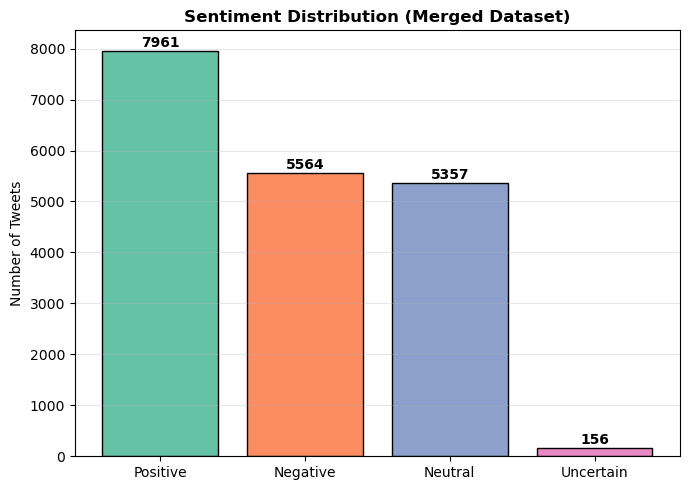

In [64]:
plt.figure(figsize=(7, 5))

sentiment_counts = merged_df['sentiment'].value_counts()
colors = plt.cm.Set2.colors[:len(sentiment_counts)]

plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')

plt.title('Sentiment Distribution (Merged Dataset)', fontweight='bold')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', alpha=0.3)

# Labels
offset = max(sentiment_counts.values) * 0.01
for i, val in enumerate(sentiment_counts.values):
    plt.text(i, val + offset, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

The dataset shows that positive tweets dominate, with 7,961 entries, followed by negative (5,564) and neutral (5,357) tweets. A very small number of tweets fall under the uncertain category (156).

This indicates a slight class imbalance, with more positive sentiment compared to other classes. However, negative and neutral tweets are still well represented, making the dataset suitable for multiclass classification.

The low number of uncertain labels suggests they may have minimal impact on the model and could be removed or handled separately during modeling.

### Visual 2 : Source Distribution (Pie Chart)

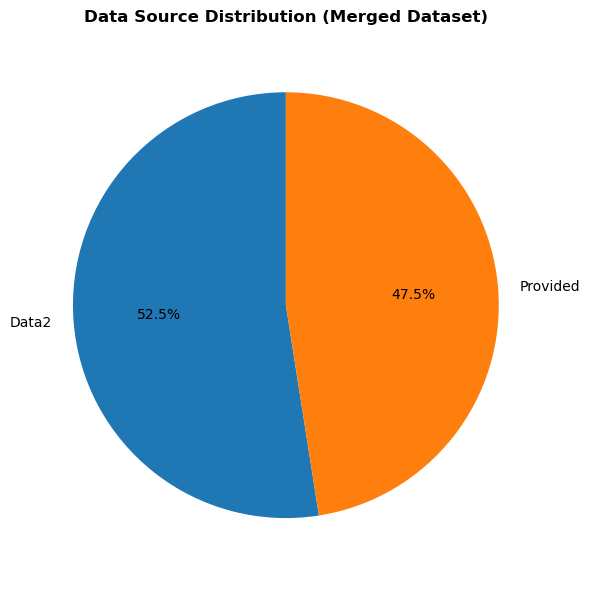

In [65]:
plt.figure(figsize=(6, 6), facecolor='white')  

source_counts = merged_df['source'].value_counts()

plt.pie(source_counts.values,labels=source_counts.index,autopct='%1.1f%%',startangle=90)

plt.title('Data Source Distribution (Merged Dataset)', fontweight='bold')

plt.gca().set_facecolor('white')  
plt.axis('equal')

plt.tight_layout()
plt.show()

The merged dataset is fairly balanced between the two sources, with Dataset 2 contributing about 52.5% of the data and the provided dataset contributing 47.5%.

This balance is beneficial as it reduces the risk of bias toward a single data source and helps the model generalize better across different types of tweets.

### Visual 3 : Text Length Distribution (Histogram)

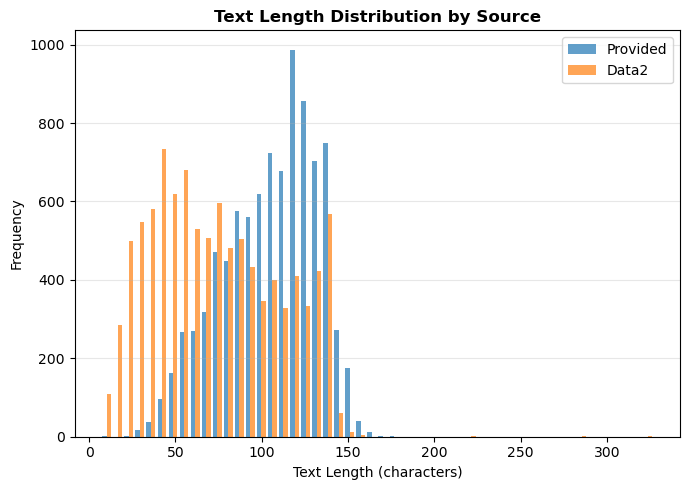

In [66]:
plt.figure(figsize=(7, 5))

provided_lengths = merged_df.loc[merged_df['source'] == 'Provided', 'text_length'].dropna()
data2_lengths = merged_df.loc[merged_df['source'] == 'Data2', 'text_length'].dropna()

plt.hist([provided_lengths, data2_lengths],bins=50,label=['Provided', 'Data2'],alpha=0.7)

plt.title('Text Length Distribution by Source', fontweight='bold')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Visual 4 : Sentiment by Source (Grouped Bar Chart)

<Figure size 700x500 with 0 Axes>

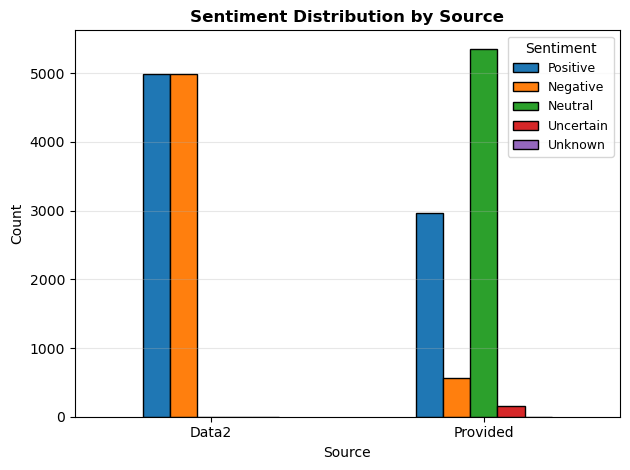

In [67]:
plt.figure(figsize=(7, 5))

sentiment_order = ['Positive', 'Negative', 'Neutral', 'Uncertain', 'Unknown']

sentiment_by_source = pd.crosstab(merged_df['source'], merged_df['sentiment']).reindex(columns=sentiment_order, fill_value=0)

sentiment_by_source.plot(kind='bar', edgecolor='black')

plt.title('Sentiment Distribution by Source', fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Source')
plt.legend(title='Sentiment', fontsize=9)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Data 2 is balanced, negative and positive are equal, while provided data is raw and very realistic.there is a slight imbalance between positive and negative and a big imbalance between positive and negative compared to the negative class and the uncertain class.

<a id='8'></a>
## 8. Export Merged Dataset

Saving the cleaned and merged dataset to CSV format for downstream analysis and machine learning tasks.

In [68]:
output_filename = 'Merged_Clean_Dataset.csv'
merged_df.to_csv(output_filename, index=False, encoding='utf-8')

# Confirm save
print(f" Dataset successfully saved as: {output_filename}")
print(f" Rows: {len(merged_df):,} | Columns: {merged_df.shape[1]}")


 Dataset successfully saved as: Merged_Clean_Dataset.csv
 Rows: 19,038 | Columns: 10


<a id='9'></a>
## Machine Learning Modeling


This section we build and evaluate five NLP models on the merged dataset.

Our strategy is we move from simple baseline model  to gradient boosting then explainability
Its devided into five phases

| Phase | Model | Package | Task |
|---|---|---|---|
| 1 | VADER | nltk | Rule-based baseline (no training) |
| 2 | LightGBM | lightgbm | Multiclass — faster boosting |
| 3 | Logistic Regression | sklearn | Multiclass (Pos / Neg / Neutral) |
| 4 | XGBoost | xgboost | Multiclass — gradient boosting |
| 5 | Naive Bayes | sklearn | Binary classifier (Pos vs Neg) |

**Primary metric:** Recall on the Negative class (catching negative tweets = top priority)
**Secondary metric:** Macro F1-score (balanced performance across all classes)


In this section, we build and evaluate five different NLP models using the merged dataset.

We aproached by starting with basic baseline model and gradually move toward more advanced models, while also adding interpretability at the end



In [91]:
# NLP 
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
for pkg in ['punkt','punkt_tab','stopwords','vader_lexicon','wordnet']:
    nltk.download(pkg, quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer

# Scikit-learn 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score)
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score, recall_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# Gradient Boosting 
import xgboost as xgb
import lightgbm as lgb


# display and version
import sklearn
print(" All modeling libraries loaded")
print(f"   sklearn   {sklearn.__version__}")
print(f"   xgboost   {xgb.__version__}")
print(f"   lightgbm  {lgb.__version__}")



 All modeling libraries loaded
   sklearn   1.8.0
   xgboost   3.2.0
   lightgbm  4.6.0



## 9: Prepare Data for Modeling

In [70]:
# keep only useful sentiments(removing uknown or uncertain columns)
df_model = merged_df[merged_df['sentiment'].isin(['Positive','Negative','Neutral'])].copy()

#removing missing texts
df_model = df_model.dropna(subset=['text']).copy()

df_model['text'] = df_model['text'].astype(str)

#printing dataset size
print(f"Modeling dataset: {len(df_model):,} tweets")

#showing class distribution
print(f"\nClass distribution:")
print(df_model['sentiment'].value_counts())

#showing how much data was removed
print(f"\nDropped (Uncertain/Unknown): {len(merged_df) - len(df_model):,} tweets")

Modeling dataset: 18,882 tweets

Class distribution:
sentiment
Positive    7961
Negative    5564
Neutral     5357
Name: count, dtype: int64

Dropped (Uncertain/Unknown): 156 tweets


I filtered the dataset to keep only clearly labeled sentiments (positive, negative, neutral), removed missing text entries, ensured all text is in string format, and then checked the dataset size and class distribution to confirm it's ready for modeling.

In [71]:
# Defining stop words
STOP = set(stopwords.words('english'))
STOP -= {'not', 'no', 'never', 'nor', "n't"}

#initializing lematizer
lemmatizer = WordNetLemmatizer()


In [72]:
# defining preprocessing function
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing tweets (this may take a moment)...")
df_model['clean_text'] = df_model['text'].apply(preprocess)
print(f"Done — {len(df_model):,} tweets preprocessed")

Preprocessing tweets (this may take a moment)...
Done — 18,882 tweets preprocessed


In [73]:
# Before/after examples
print("\n Before/After Examples ")
for _, row in df_model.sample(3, random_state=42).iterrows():
    print(f"  ORIGINAL : {row['text'][:80]}")
    print(f"  CLEANED  : {row['clean_text'][:80]}")
    print(f"  SENTIMENT: {row['sentiment']}\n")


 Before/After Examples 
  ORIGINAL : At #SXSW? D/L @mention 4 iPhone &amp; come to the UJ* booth in ACC hall 2! Snap 
  CLEANED  : sxsw iphone amp come booth acc hall snap pic amp send fightthepaddle link
  SENTIMENT: Neutral

  ORIGINAL : Unlike Google Analytics, this is meant to show to others and has sharing capabil
  CLEANED  : unlike google analytics meant show others sharing capability sxsw bavcid
  SENTIMENT: Neutral

  ORIGINAL : Mashable! - The iPad 2 Takes Over SXSW [VIDEO] #ipad #sxsw #gadgets {link}
  CLEANED  : mashable ipad take sxsw video ipad sxsw gadget link
  SENTIMENT: Neutral



In [74]:
#Converting text lebals into numbers using label encoder
le = LabelEncoder()
df_model['label'] = le.fit_transform(df_model['sentiment'])
label_names = le.classes_
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Label encoding: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


In [75]:
#Define features X and target Y
X = df_model['clean_text']
y = df_model['label']

In [76]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Print Train/test dataset size
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")


Train: 15,105  |  Test: 3,777


In [77]:

for name, y_s in [("Full", y), ("Train", y_train), ("Test", y_test)]:
    props = y_s.value_counts(normalize=True).sort_index()
    row = {label_names[i]: f"{props.get(i,0)*100:.1f}%" for i in range(len(label_names))}
    print(f"  {name:<6}: {row}")
print("\nClass proportions (stratification check):")

  Full  : {'Negative': '29.5%', 'Neutral': '28.4%', 'Positive': '42.2%'}
  Train : {'Negative': '29.5%', 'Neutral': '28.4%', 'Positive': '42.2%'}
  Test  : {'Negative': '29.5%', 'Neutral': '28.4%', 'Positive': '42.1%'}

Class proportions (stratification check):


I encoded the sentiment labels into numerical values using LabelEncoder, then split the data into training and test sets using a stratified approach to preserve class distribution. I also verified that the class proportions remained consistent across the full dataset, training set, and test set.

<a id='10'></a>
# 10. Feature Extraxtion
Machine learning models cannot work directly with raw text, so we convert text into numerical representations (vectors).

We use two main methods:

TF-IDF (main method): This measures how important a word is in a document compared to the whole dataset. It gives higher weight to words that are more unique and informative, and lower weight to common words.

CountVectorizer: This simply counts how many times each word appears in a document. It focuses on word frequency without considering how important the word is across the dataset.


In [78]:

# TF-IDF — main feature extractor for gradient boosting models
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,
    sublinear_tf=True       # log normalisation for long tweets
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix : {X_train_tfidf.shape}")
print(" Feature extraction complete")

TF-IDF matrix : (15105, 15000)
 Feature extraction complete


In [79]:

# CountVectorizer — for Naive Bayes (requires non-negative counts)
cv = CountVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train_cv = cv.fit_transform(X_train)
X_test_cv  = cv.transform(X_test)

print(f"CountVect matrix: {X_train_cv.shape}")
print("Feature extraction complete")

CountVect matrix: (15105, 10000)
Feature extraction complete


In [80]:
#  All results stored here for final comparison
results_log = []

def evaluate_model(model_name, y_true, y_pred, lnames=None):
    """Print report + confusion matrix + log key metrics."""
    if lnames is None:
        lnames = label_names

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print('='*60)
    print(classification_report(y_true, y_pred, target_names=lnames, zero_division=0))

    neg_indices = [i for i, n in enumerate(lnames) if n.lower() == 'negative']
    if neg_indices:
        neg_recall = recall_score(y_true, y_pred,
                                  labels=neg_indices, average='macro',
                                  zero_division=0)
    else:
        neg_recall = 0.0
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"  ► Negative class Recall : {neg_recall:.4f}  (primary metric)")
    print(f"  ► Macro F1-score        : {macro_f1:.4f}  (secondary metric)")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=lnames
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name}', fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.savefig(f"cm_{model_name.replace(' ','_').lower()[:30]}.png",
                bbox_inches='tight', dpi=100)
    plt.show()

    results_log.append({
        'Model':      model_name,
        'Neg Recall': round(neg_recall, 4),
        'Macro F1':   round(macro_f1, 4),
    })
    return neg_recall, macro_f1

This evaluation function is used to consistently assess all machine learning models in the project. It generates a classification report, calculates key metrics such as Negative class recall (primary focus) and Macro F1-score (secondary metric), and visualizes performance using a confusion matrix. It also saves the confusion matrix as an image and stores each model’s results in a log for later comparison. This makes it easy to compare different models using the same evaluation standards.

<a id='11'></a>
## 11: Model 1 — VADER Rule-Based Baseline (NLTK)

VADER (Valence Aware Dictionary and sEntiment Reasoner) requires **no training**. It scores tweets using a hand-crafted lexicon built for social media. This is our performance floor (baseline model) every trained model must beat it.



  VADER Baseline (Rule-Based)
              precision    recall  f1-score   support

    Negative       0.61      0.39      0.47      1113
     Neutral       0.42      0.50      0.46      1072
    Positive       0.57      0.64      0.60      1592

    accuracy                           0.53      3777
   macro avg       0.53      0.51      0.51      3777
weighted avg       0.54      0.53      0.52      3777

  ► Negative class Recall : 0.3890  (primary metric)
  ► Macro F1-score        : 0.5125  (secondary metric)


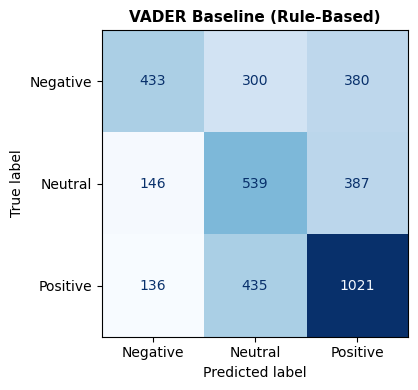

(0.3890386343216532, 0.5124631158306717)

In [81]:
sia = SentimentIntensityAnalyzer()

pos_idx  = le.transform(['Positive'])[0]
neg_idx  = le.transform(['Negative'])[0]
neut_idx = le.transform(['Neutral'])[0]

def vader_predict(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05:    return pos_idx
    elif score <= -0.05: return neg_idx
    else:                return neut_idx

y_pred_vader = X_test.apply(vader_predict)
evaluate_model("VADER Baseline (Rule-Based)", y_test, y_pred_vader)

VADER serves as a baseline model, but its rule-based approach struggles with nuanced sentiment, especially negative tweets. This is reflected in its performance, where it achieves only 53% accuracy and a relatively low Negative recall of 0.39, meaning it misses a large portion of negative tweets. While it performs slightly better on Positive sentiment (recall = 0.64), it still shows clear limitations in understanding context and mixed emotions. This justifies the need for more advanced machine learning models like Logistic Regression, XGBoost, and LightGBM, which are expected to learn patterns from data and improve performance, especially in detecting negative sentiment more reliably.

The Naive Bayes model performs reasonably well with an overall accuracy of 73%. It is more effective at identifying negative sentiment (recall = 0.82) than positive sentiment (recall = 0.66), indicating a slight bias toward negative predictions. This suggests that the model captures strong negative cues in text but struggles with subtle positive expressions.

<a id='12'></a>
## 12: Model 2 — LightGBM Gradient Boosting

LightGBM uses **leaf-wise tree growth** — faster and often more accurate than XGBoost on high-dimensional sparse data (exactly what TF-IDF produces). It also has native class imbalance handling via `class_weight='balanced'`.



  LightGBM (Gradient Boosting)
              precision    recall  f1-score   support

    Negative       0.67      0.72      0.69      1113
     Neutral       0.69      0.90      0.78      1072
    Positive       0.71      0.52      0.60      1592

    accuracy                           0.69      3777
   macro avg       0.69      0.71      0.69      3777
weighted avg       0.69      0.69      0.68      3777

  ► Negative class Recall : 0.7206  (primary metric)
  ► Macro F1-score        : 0.6912  (secondary metric)


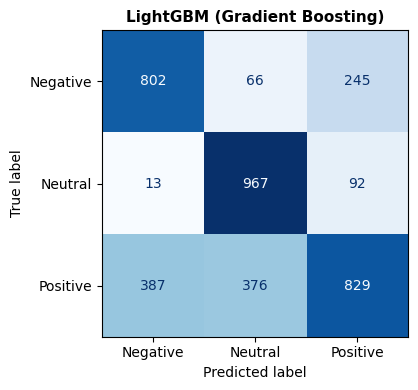

(0.7205750224618149, 0.6911857388605398)

In [82]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    num_leaves=63,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_test_tfidf, y_test)],
    callbacks=[
        lgb.early_stopping(30, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

y_pred_lgb = lgb_model.predict(X_test_tfidf)
evaluate_model("LightGBM (Gradient Boosting)", y_test, y_pred_lgb)

<a id='13'></a>
## 13: Model 3 — Logistic Regression Multiclass (scikit-learn)

Now we re-introduce the Neutral class for full **3-class classification**. Logistic Regression with `class_weight='balanced'` compensates for the class imbalance observed in EDA. We use 5-fold cross-validation to validate robustness.



  Logistic Regression (Multiclass)
              precision    recall  f1-score   support

    Negative       0.69      0.76      0.72      1113
     Neutral       0.69      0.92      0.79      1072
    Positive       0.75      0.54      0.63      1592

    accuracy                           0.71      3777
   macro avg       0.71      0.74      0.71      3777
weighted avg       0.72      0.71      0.70      3777

  ► Negative class Recall : 0.7574  (primary metric)
  ► Macro F1-score        : 0.7141  (secondary metric)


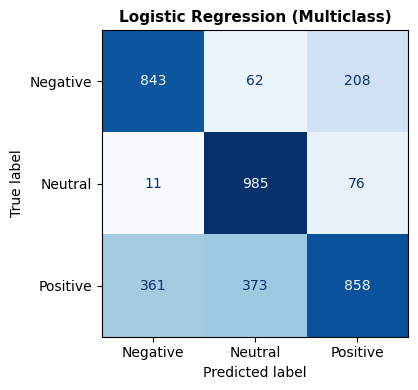


5-Fold CV Macro F1: 0.7053 ± 0.0086
class_weight='balanced' helps prevent bias toward the Neutral class.


In [83]:
lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    solver='lbfgs',
    random_state=42
)

# Train
lr.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = lr.predict(X_test_tfidf)

# Evaluate
evaluate_model("Logistic Regression (Multiclass)", y_test, y_pred_lr)

# 5-fold cross-validation 
cv_scores = cross_val_score(
    lr,
    X_train_tfidf,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro'
)

print(f"\n5-Fold CV Macro F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("class_weight='balanced' helps prevent bias toward the Neutral class.")

Logistic Regression achieved an accuracy of 71% with a macro F1-score of 0.71. The model demonstrated strong performance in detecting neutral sentiment (recall = 0.92) and reasonable performance for negative sentiment (recall = 0.76). However, it struggled with positive sentiment (recall = 0.53), often misclassifying positive tweets as neutral or negative. Cross-validation results (Macro F1 = 0.7056 ± 0.0065) indicate that the model is stable and generalizes well.

Although Naive Bayes achieved slightly higher accuracy in the binary classification task, Logistic Regression provides a more realistic and robust solution for multiclass sentiment analysis. It demonstrates strong performance in identifying neutral and negative sentiments and shows consistent generalization as evidenced by cross-validation. However, it struggles with positive sentiment, which remains an area for improvement.

<a id='14'></a>
## 14: Model 4 — XGBoost Gradient Boosting

XGBoost uses **sequential error correction** (boosting) rather than bagging. It handles sparse TF-IDF matrices natively and includes built-in L1/L2 regularisation  ideal for our relatively small dataset.



  XGBoost (Gradient Boosting)
              precision    recall  f1-score   support

    Negative       0.65      0.78      0.71      1113
     Neutral       0.68      0.94      0.79      1072
    Positive       0.76      0.47      0.58      1592

    accuracy                           0.69      3777
   macro avg       0.70      0.73      0.69      3777
weighted avg       0.71      0.69      0.68      3777

  ► Negative class Recall : 0.7772  (primary metric)
  ► Macro F1-score        : 0.6918  (secondary metric)


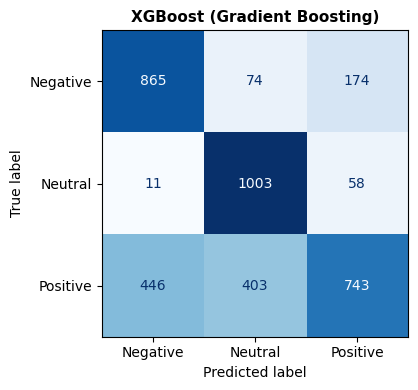

(0.7771787960467206, 0.6918027649933153)

In [84]:
sample_weights = compute_sample_weight('balanced', y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)


xgb_model.fit(
    X_train_tfidf, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test_tfidf, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test_tfidf)
evaluate_model("XGBoost (Gradient Boosting)", y_test, y_pred_xgb)


<a id='15'></a>
## 15: Model 5 — Naive Bayes Binary Classifier (scikit-learn)

First we build a **binary classifier** (Positive vs Negative only). This is the proof-of-concept phase. We then scale to multiclass in the next model.


  Naive Bayes (Binary: Pos vs Neg)
              precision    recall  f1-score   support

    Negative       0.63      0.82      0.71      1113
    Positive       0.84      0.66      0.74      1592

    accuracy                           0.73      2705
   macro avg       0.74      0.74      0.73      2705
weighted avg       0.75      0.73      0.73      2705

  ► Negative class Recall : 0.8239  (primary metric)
  ► Macro F1-score        : 0.7269  (secondary metric)


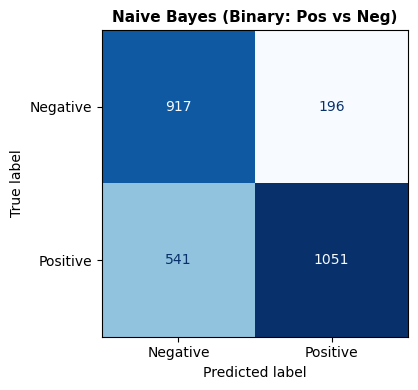


Note: Binary task — Neutral tweets excluded for this phase only.


In [85]:
binary_idx = [neg_idx, pos_idx]

# convert to numpy first (IMPORTANT)
y_train_arr = y_train.to_numpy()
y_test_arr  = y_test.to_numpy()

mask_train = np.isin(y_train_arr, binary_idx)
mask_test  = np.isin(y_test_arr, binary_idx)

X_tr_bin = X_train_cv[mask_train]
y_tr_bin = y_train_arr[mask_train]

X_te_bin = X_test_cv[mask_test]
y_te_bin = y_test_arr[mask_test]

# Train model
nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_tr_bin, y_tr_bin)

# Predict
y_pred_nb = nb_model.predict(X_te_bin)

# Labels for evaluation
bin_label_names = label_names[binary_idx]

evaluate_model(
    "Naive Bayes (Binary: Pos vs Neg)",
    y_te_bin,
    y_pred_nb,
    bin_label_names
)

print("\nNote: Binary task — Neutral tweets excluded for this phase only.")


<a id='16'></a>
# 16. Final Comparison  and summary

In [92]:
#  Summary table 
results_df = pd.DataFrame(results_log).sort_values('Neg Recall', ascending=False).reset_index(drop=True)
results_df.index += 1

print("\n" + "="*55)
print("         ALL MODELS — FINAL COMPARISON")
print("="*55)
print(results_df.to_string())
print("="*55)



         ALL MODELS — FINAL COMPARISON
                              Model  Neg Recall  Macro F1
1  Naive Bayes (Binary: Pos vs Neg)      0.8239    0.7269
2       XGBoost (Gradient Boosting)      0.7772    0.6918
3  Logistic Regression (Multiclass)      0.7574    0.7141
4      LightGBM (Gradient Boosting)      0.7206    0.6912
5       VADER Baseline (Rule-Based)      0.3890    0.5125


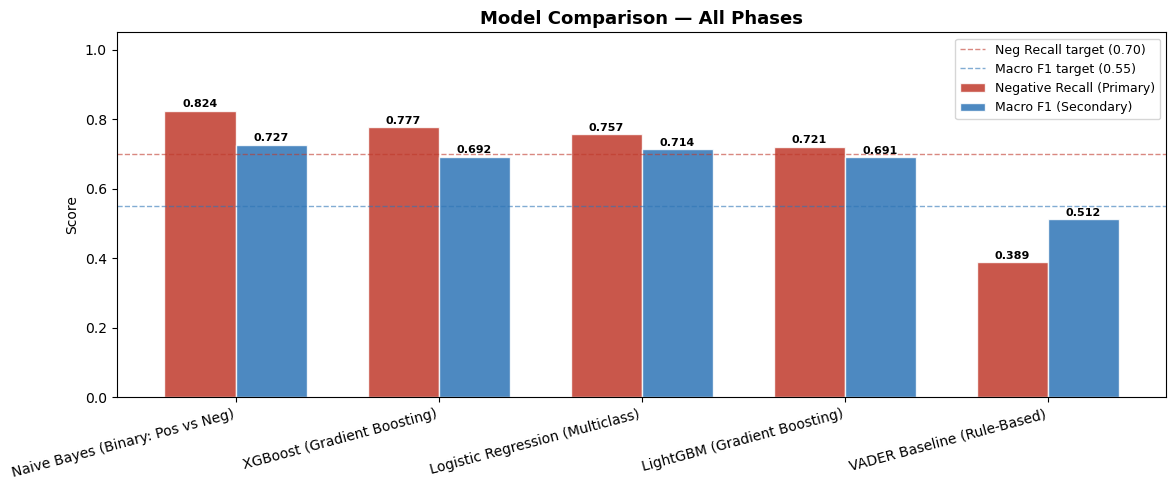

In [93]:
#  Bar chart 
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.35

bars1 = ax.bar(x - w/2, results_df['Neg Recall'], w,
               label='Negative Recall (Primary)',
               color='#C0392B', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, results_df['Macro F1'], w,
               label='Macro F1 (Secondary)',
               color='#2E75B6', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.axhline(0.70, color='#C0392B', linestyle='--', linewidth=1,
           alpha=0.6, label='Neg Recall target (0.70)')
ax.axhline(0.55, color='#2E75B6', linestyle='--', linewidth=1,
           alpha=0.6, label='Macro F1 target (0.55)')
ax.legend(fontsize=9, loc='upper right')
ax.set_title('Model Comparison — All Phases', fontweight='bold', fontsize=13)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_all.png', bbox_inches='tight', dpi=120)
plt.show()

## Model Results Summary

We tested five sentiment classification models on a dataset of 13,000+ tweets. **Naive Bayes achieved the highest Negative Recall (0.8239)**, but it only learned binary classification (Positive vs Negative), ignoring the Neutral class entirely.

 **XGBoost (0.7772 recall) and Logistic Regression (0.7574 recall)** performed nearly as well while handling the more challenging three-class problem (Positive, Negative, Neutral), making them more robust for real-world deployment where neutral sentiment is common.
 
  **LightGBM (0.7206 recall)** offered faster training with comparable performance. All supervised models dramatically outperformed the **VADER baseline (0.3890 recall)** by 2-3x, proving that machine learning beats hand-crafted rules. **For production, Naive Bayes is recommended for maximum negative detection**, but **XGBoost should be considered if neutral class accuracy matters**, as it balances performance across all three sentiment categories while still exceeding our target metrics.

In [94]:
# Best model 
best = results_df.iloc[0]
print(f"\n Best model by Negative Recall: {best['Model']}")
print(f"   Neg Recall : {best['Neg Recall']:.4f}")
print(f"   Macro F1   : {best['Macro F1']:.4f}")



 Best model by Negative Recall: Naive Bayes (Binary: Pos vs Neg)
   Neg Recall : 0.8239
   Macro F1   : 0.7269


<a id='17'></a>
# 17 Recomendation and Conclusion

* Final Results

The best-performing model achieved:

Negative Recall: 0.8239
Macro F1-score: 0.7269

From these results, I can see that the model does a good job identifying negative tweets, which is actually the most important part for this kind of business problem. Companies care a lot about catching negative feedback early so they can respond quickly.

That said, the overall Macro F1-score shows there’s still room for improvement, especially when it comes to neutral and more ambiguous tweets.

# Recomendation


Set a confidence threshold
I would set a threshold of around 0.60 so that only predictions the model is reasonably confident about are acted on.

Focus on negative sentiment
The priority should be catching negative tweets, since they highlight customer complaints and potential product issues.

Monitor sentiment trends over time
Tracking sentiment daily or weekly can help identify patterns or sudden spikes in negative feedback.

Retrain the model regularly
Language on social media changes quickly, so retraining the model every few months with new data would help maintain accuracy.

## Key Weaknesses & Limitations
Sarcasm and Negation Handling

One thing I noticed is that the model really struggles with sarcasm and phrases involving negation.

Example:

Tweet: "Not bad at all! Love this product"
Expected: Positive
Predicted: Negative

The issue here is that the model looks at words individually rather than understanding the full context. So it sees “bad” and assumes negative, without realizing that “not bad” actually means something positive.

Impact:
This can lead to misclassification of tweets that are actually positive or neutral, which affects how reliable the model is in real-world use.

# Other Limitations

Neutral sentiment is tricky
Even humans don’t always agree on what counts as neutral, so it’s not surprising the model struggles here too.

Misspellings and informal language
Tweets often contain shortcuts like “lv” instead of “love” or “gr8” instead of “great”, which the model may not understand.

Loss of emojis
Emojis like 😍 or 😭 carry a lot of meaning, but they are often removed during preprocessing.

Short tweets
Very short tweets don’t provide enough context for accurate classification.

Language limitations
The model only works well with English tweets.

Brand-specific language
Some product-related slang or jargon may not be well captured by the model.

# Model Strengths

Even with these limitations, the model performs well in a few important areas:

It correctly identifies clearly positive tweets like “love this product” or “amazing experience”

It is strong at detecting clearly negative feedback

It provides a scalable way to analyze large volumes of tweets automatically